Biometrich Technologies and Behavioural Security
# **<center>Tutorial 2 - Fingerprint Feature Extraction and Comparison</center>**

In this tutorial, we are going to explore three main aspects of fingerprint recognition:

1. **Fingerprint enhancement:** Improves the “quality” (visual quality) of the fingerprint to make the feature extraction stage easier.
2. **Feature extraction:** Involves locating *minutiae* (ridge discontinuities) in fingerprint patterns.
3. **Fingerprint comparison:** Involves comparing the minutiae across fingerprints to see if the fingerprints *match* (i.e. belong to the same person).

The feature extraction and comparison will be conducted using the "mindtct" and "bozorth3" packages obtained from NIST's open-source Biometric Image Software (NBIS), available at <a href="https://www.nist.gov/itl/iad/image-group/products-and-services/image-group-open-source-server-nigos#Releases.">this link</a>. For further details, you can look at the information provided in the user guides:

1. <i><a href="https://ws680.nist.gov/publication/get_pdf.cfm?pub_id=51097">mindtct</a></i>

2. <i><a href="https://nvlpubs.nist.gov/nistpubs/Legacy/IR/nistir7391.pdf">bozorth</a></i>


## Step 1: Load data and packages in your VM

The following bit of code allows you to load in your "Files" section all the necessary for this tutorial:

1.   A small dataset of fingerprint samples.
2.   An <a href=https://github.com/Utkarsh-Deshmukh/Fingerprint-Enhancement-Python>open source</a> code to perform image enhancement.
3. mindtct and bozorth3 packages.

It's basically the same procedure you have seen in Tutorial 1, namely a loading of shared Google Drive contents. If you don't see the files at the end of the process, press the *Refresh* button.


In [ ]:
#!pip install gdown --quiet
from google.colab import auth
auth.authenticate_user()

# from pydrive.auth import GoogleAuth
# from pydrive.drive import GoogleDrive
# from oauth2client.client import GoogleCredentials

# gauth = GoogleAuth()
# gauth.credentials = GoogleCredentials.get_application_default()
# drive = GoogleDrive(gauth)


#downloaded = drive.CreateFile({'id':"1bOI_Wy77foeBPJVp_ITHpyhq_GwJtUpO"})   # replace the id with id of file you want to access
#downloaded.GetContentFile('Tutorial2.zip')

!gdown --id "1bOI_Wy77foeBPJVp_ITHpyhq_GwJtUpO" -O Tutorial2.zip
!unzip Tutorial2.zip
clear_output()
print('Done! Press the Refresh button if files are not visible.')

Done! Press the Refresh button if files are not visible.


In [ ]:
#code for progress bar

from IPython.display import HTML, display
import time

def progress(value, max=100):
    return HTML("""
        <progress
            value='{value}'
            max='{max}',
            style='width: 100%'
        >
            {value}
        </progress>
    """.format(value=value, max=max))

### Step 1.1: Dataset structure

The fingerprint images are located in the "Dataset" directory. There are a total of 400 fingerprint images, extracted from the <a href= https://pralab.diee.unica.it/sites/default/files/C62_BTAS2015.pdf>LivDet 2015</a> dataset.
This consists of 10 fingerprint samples captured from each of 10 fingers of different subjects.
We choose both different identities and fingers randomly, but to have always 10 samples per finger. The images are labelled with the user ID (which ranges from 1 to 40) and fingerprint sample ID (which ranges from 0 to 9). To the aim of this tutorial, we consider fingerprints that belong to the same user like they weren't. So, for example:

 - Fingerprint **<font color='green'>01</font>_<font color='red'>0</font>** = the **<font color='red'>1st</font>** fingerprint sample captured from user **<font color='green'>1</font>**
 - Fingerprint **<font color='green'>02</font>_<font color='red'>2</font>** = the **<font color='red'>3rd</font>** fingerprint sample captured from user **<font color='green'>2</font>**
 - and so on...

To appreciate the so-called intra-class variations, you can display all 10 fingerprint samples acquired from a specific user running the code below and modifying the user variable at will:

In [ ]:
import math
import cv2
import numpy as np
from matplotlib import pyplot as plt


def shows(user):
  fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(20, 6), sharex=True, sharey=True)
  user = user.zfill(2)
  for i in range(10):
    img = cv2.imread('Dataset/'+user+'_'+str(i)+'.jpeg')
    axes[int(math.floor(i/5)),int(i-5*(math.floor(i/5)))].set_title('Sample '+str(i), fontsize=20)
    axes[int(math.floor(i/5)),int(i-5*(math.floor(i/5)))].axis('off')
    axes[int(math.floor(i/5)),int(i-5*(math.floor(i/5)))].imshow(img, cmap=plt.cm.gray)
  plt.suptitle('User '+ user, fontsize=28, fontweight="bold")
  fig.tight_layout()
  plt.show()


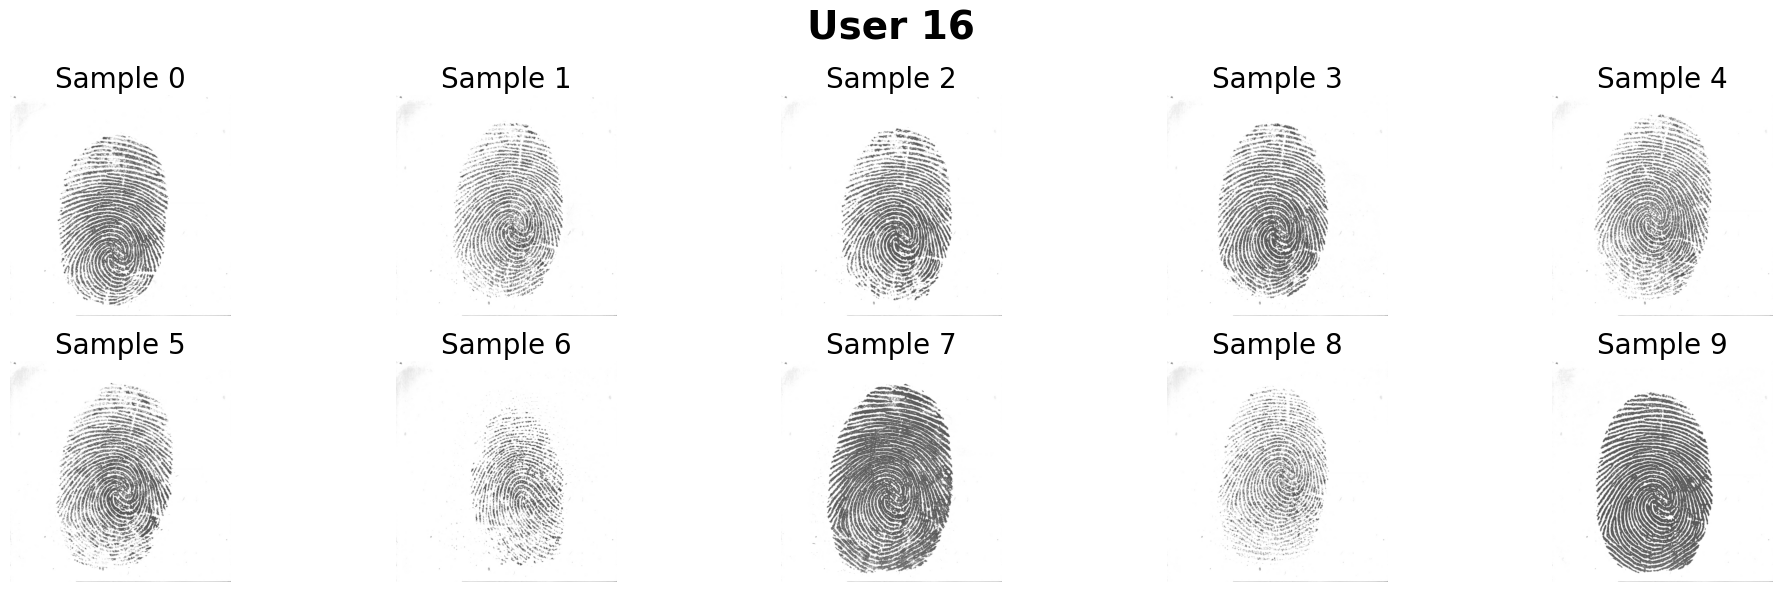

In [ ]:
#@title Take a look at the dataset by changing the User ID here [01 - 40]. { run: "auto" }

User = 16 #@param {type:"slider", min:1, max:40, step:1}
shows(str(User))

## Step 2: Fingerprint Enhancement


A critical step in automatic fingerprint matching is to automatically and reliably extract minutiae from the input fingerprint
images. However, the performance of a minutiae extraction algorithm relies heavily on the quality of the input fingerprint images. In
order to ensure that the performance of an automatic fingerprint identification/verification system will be robust with respect to the
quality of input fingerprint images, it is essential to incorporate a fingerprint enhancement algorithm in the minutiae extraction
module.

A typical algorithm provides:

1.   Thresholding: a threshold applied to the image pixels is a simple way to binarise the fingerprint.
2.   Gabor Filtering: A bank of Gabor filters which is tuned to local
ridge orientation and ridge frequency (same as show in slide 40 of Ch3 Lecture).
3. Thinning/skeletonization



**<center><font size='4' color='green'> You can modify this code </font></center>**

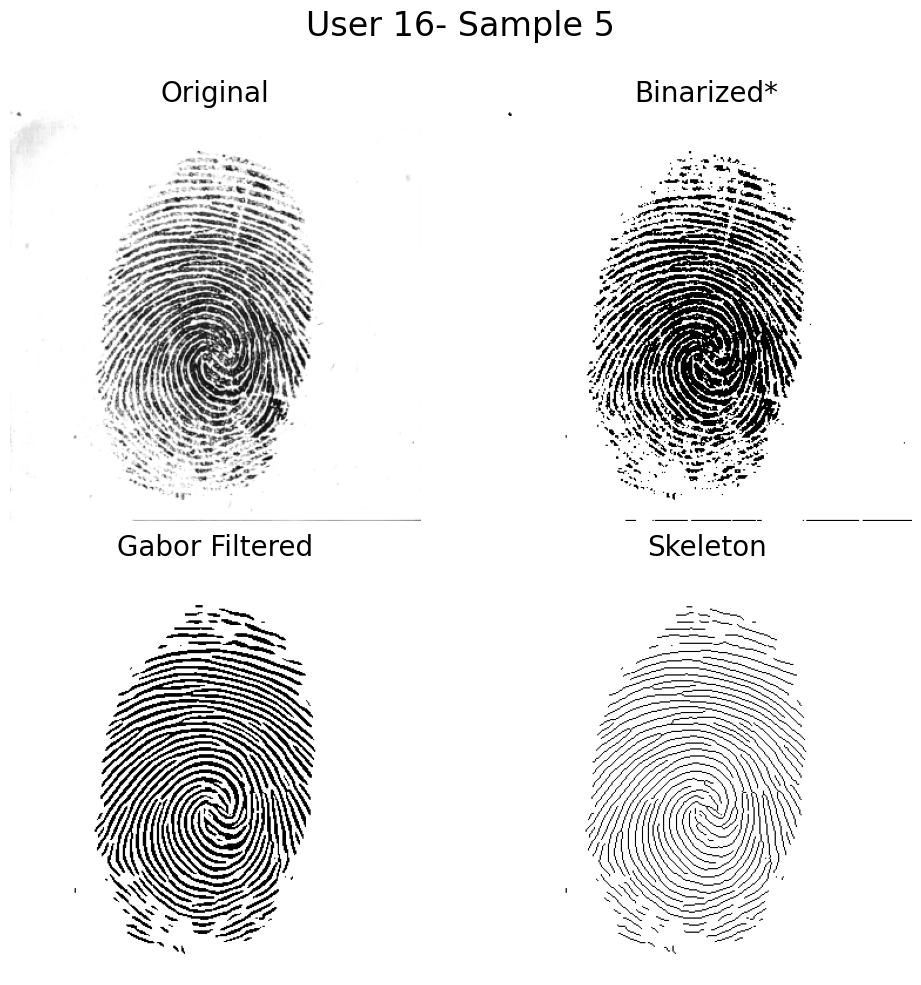

In [ ]:
from skimage import feature
from skimage.morphology import thin, skeletonize
from image_enhance import image_enhance

user = '16'  # <---- Change the User ID here [01 - 40].
sample = '5' # <---- Change the sample number here [0 - 9].

img = cv2.imread('Dataset/'+user+'_'+sample+'.jpeg')

if(len(img.shape)>2):
  img = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)

rows,cols= np.shape(img);
aspect_ratio = np.double(rows)/np.double(cols);
new_rows = 350;
new_cols = new_rows/aspect_ratio;
img = cv2.resize(img,(np.int64(new_cols),np.int64(new_rows)));

#perform enhancement
B=img[:,:]>200 #Binarised
enhanced_img = image_enhance(B); #perform enhancement (Gabor Filter)
enhanced_img = enhanced_img*1

thin = 1-thin(enhanced_img)

#show images
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 10), sharex=True, sharey=True)
fig.suptitle('User '+ user + '- Sample ' +sample, fontsize=24)
axes[0,0].imshow(img, cmap=plt.cm.gray)
axes[0,0].axis('off')
axes[0,0].set_title('Original', fontsize=20)

axes[0,1].imshow(B, vmin=0,vmax=1,cmap=plt.cm.gray)
axes[0,1].axis('off')
axes[0,1].set_title('Binarized*', fontsize=20)

axes[1,0].imshow(1-enhanced_img, cmap=plt.cm.gray)
axes[1,0].axis('off')
axes[1,0].set_title('Gabor Filtered', fontsize=20)

axes[1,1].imshow(thin, cmap=plt.cm.gray)
axes[1,1].axis('off')
axes[1,1].set_title('Skeleton', fontsize=20)

fig.tight_layout()
fig.subplots_adjust(top=0.88)
plt.show()


## Step 3: Feature Extraction (minutiae)

This is a crucial part of a biometric system. The more the feature vector is representative of a specific fingeprint image, the more accurate is our system.
The most common minutia types, which are considered in this tutorial, are the bifurcation (when a ridge splits into two ridges) and the termination (when a ridge ends prematurely). As we have just see, it's important to submit to the feature extractor an enhanced image, to make the minutiae recognition easier.
To this aim, we can take advantage of automatic enhancement of ***mindtct*** package, by specifying the option **'-b'** in the command line.
Moreover, if we add the option **'-m1'** the minutiae points are written according to ANSI INCITS 378-2004.

The *output* of the mindtct algorithm is a number of different files for each fingerprint, which are stored inside the same directory, with the same name of the fingerprint sample.  These files are the results of the three main stages showed in slide 13 of this tutorial.

To extract the minutiae from each image, run the following code:

In [ ]:
import os
import subprocess
import numpy as np
samples = os.listdir('/content/Dataset') #path of the dataset
!chmod 755 mindtct #allows to read and execute the file
print('Current Progress...')
out = display(progress(0, len(samples)-1), display_id=True)

for idx,fp in enumerate(samples):
  #Check slide 14 of this Tutorial and understand the command expressed by the string below
  os.system('/content/mindtct -m1 -b /content/Dataset/'+ fp + ' /content/Dataset/' + fp[0:4])
  out.update(progress(idx, len(samples)-1))

Current Progress...


### Step 3.1 Take a look at the output

With the following code, an interesting image is generated. We're looking at the overlapping of 3 mindtct output files:

1.   generic_sample.*brw*, that is the **binarised** fingerprint image.
2.   generic_sample.*qm*, the **quality map**, that represents regions in the image having varying levels of quality.
3.   generic_sample.*min*, reports the **minutiae** detection results.

If you are curious, further information of these and the other outputs can be found <a href=http://ffpis.sourceforge.net/man/mindtct.html> here </a>


In [ ]:
def read_minutiae(filename):
    # Extract minutiae attributes
    with open(filename) as f:
        minutiae_temp = [line.strip().split(':') for line in f][4:]
    coords = np.array([ln[1].split(',') for ln in minutiae_temp], dtype=int)
    xs = coords[:, 0]
    ys = coords[:, 1]
    angles = np.array([ln[2] for ln in minutiae_temp], dtype=int)
    types = np.array([ln[4].strip() for ln in minutiae_temp]) # strip() removes the space after the minutia type
    # Calculate start and end coordinates of vectors representing minutiae coordinates and angles
    num_minutiae = len(xs)
    line_len = 20
    start_xs = np.array(xs)
    start_ys = np.array(ys)
    angles_rad = angles * 11.25 / 180.0 * math.pi # Convert angles to radians
    end_xs = np.array([start_xs[ind] + line_len * math.sin(angles_rad[ind]) for ind in range(0, num_minutiae)])
    end_ys = np.array([start_ys[ind] - line_len * math.cos(angles_rad[ind]) for ind in range(0, num_minutiae)])

    return start_xs, end_xs, start_ys, end_ys, types

# Function to display the minutiae on the binarised image, on top of the Quality Map
def display_fp(filename,display_quality,display_minutiae):

    plt.figure(figsize=(10, 10))

    if(display_minutiae):
      # Read minutiae attributes, and calculate start and end coordinates of vectors representing minutiae coordinates and angles
      [start_xs, end_xs, start_ys, end_ys, types] = read_minutiae(filename + '.min')
      # Plot bifurcation (BIF) minutiae coordinates and angles
      bif_mask = types == 'BIF'
      plt.plot(start_xs[bif_mask], start_ys[bif_mask], 's', markeredgecolor = 'red', markerfacecolor = 'None')
      plt.plot([start_xs[bif_mask], end_xs[bif_mask]], [start_ys[bif_mask], end_ys[bif_mask]], color = 'red')
      # Plot termination/ridge ending (RIG) minutiae coordinates and angles
      rig_mask = types == 'RIG'
      plt.plot(start_xs[rig_mask], start_ys[rig_mask], 'o', markeredgecolor = 'blue', markerfacecolor = 'None')
      plt.plot(np.array([start_xs[rig_mask], end_xs[rig_mask]]), np.array([start_ys[rig_mask], end_ys[rig_mask]]), color = 'blue')

      bin_img = bytearray(open(filename + '.brw', 'rb').read()) # load binarised
      dim=(500,500)
      bin_img = np.reshape(bin_img,dim)
      plt.imshow(bin_img, alpha=0.5,cmap='gray') #change alpha to change opaqueness
      tit = 'Minutiae for User %s, Sample %s' % (filename[17:19],filename[20])
    else:

      bin_img = bytearray(open(filename + '.brw', 'rb').read()) # load binarised
      dim=(500,500)
      bin_img = np.reshape(bin_img,dim)
      plt.imshow(bin_img, alpha=1,cmap='gray') #change alpha to change opaqueness
      tit = 'Binarized image for User %s, Sample %s' % (filename[17:19],filename[20])

    if(display_quality):
      with open(filename + '.qm') as f: #load quality map
              qm_temp = [list(filter(None, ln[0].split(' '))) for ln in [line.strip().split(',') for line in f]]
      qm = np.array(qm_temp, dtype=float)
      qm_expanded = np.repeat(qm, 8, axis = 0)
      qm_expanded = np.repeat(qm_expanded, 8, axis = 1)
      # Plot Quality Map
      plt.imshow(qm_expanded, cmap = plt.cm.get_cmap('prism', 5), alpha = 0.3)
      plt.colorbar(ticks = range(5), label = 'Fingerprint image quality')
      plt.clim(-0.5, 4.5)
      tit = 'Minutiae and Quality Map for User %s, Sample %s' % (filename[17:19],filename[20])


    # Display the minutiae and Quality Map on the binarised fingerprint image
    plt.title(tit)
    plt.show()




/tmp/ipython-input-389402958.py:58: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  plt.imshow(qm_expanded, cmap = plt.cm.get_cmap('prism', 5), alpha = 0.3)


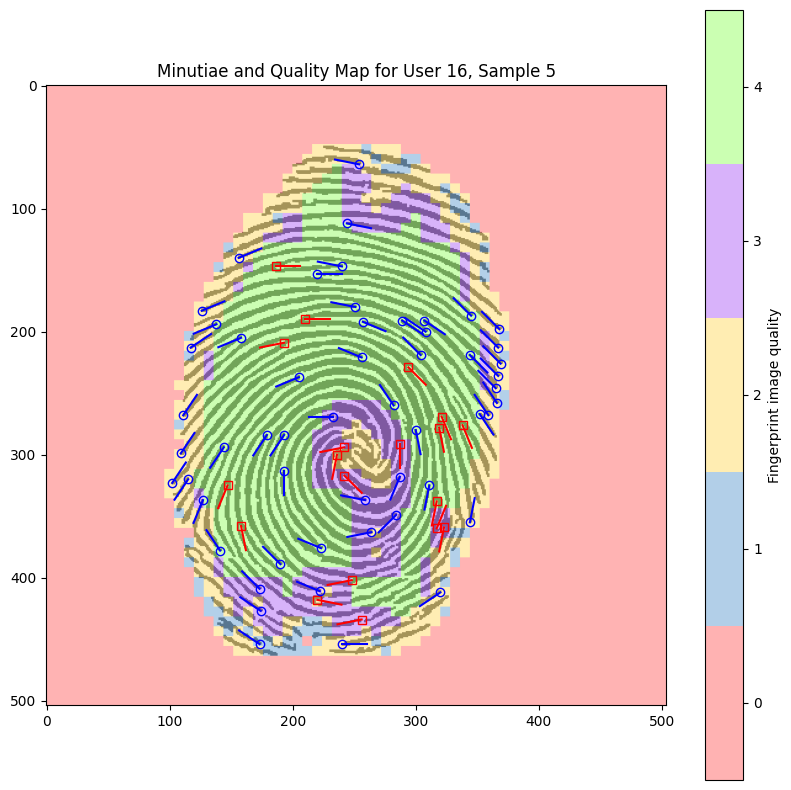

In [ ]:
#@title Display the minutiae on the binarized image, on top of the Quality Map

User = 16 #@param {type: "slider", min: 1, max: 40, step:1}
Sample = 4 #@param {type: "slider", min: 0, max: 9, step:1}
display_minutiae = True #@param {type:"boolean"}
display_quality = True #@param {type:"boolean"}


display_fp('/content/Dataset/'+ str(User).zfill(2) +'_' + sample,display_quality,display_minutiae)

## Step 4: Fingerprint Matching

Finally, we can get our hands dirty with the last step: **fingerprint matching**. Comparing fingerprint A to fingerprint B means that we try to determine whether A's minutiae match B's minutiae (in terms of the minutiae attributes, such as their locations, orientations and types). Depending on the minutiae patterns similarity, the bozorth3 algorithm computes the so-called **match score**: the higher it is, the more closely two fingerprints match.



Fingerprint comparison can be done in one of two modes: **verification** or **identification**. We will look at each recognition mode in turn.

### Step 4.1: Verification mode

In the verification mode, we conduct a ***1-to-1*** comparison between the **gallery** fingerprint (i.e., the one enrolled in our database) and the **probe** fingerprint (i.e., the one presented during authentication). **<font color=red>The point of verification is to determine whether a person IS who they say they are.</font>**

The code below compute the match score between the same two fingerprint samples. Can you guess what is happening?

In [ ]:
probe_fingerprint = '/content/Dataset/07_0.xyt'
gallery_fingerprint = '/content/Dataset/07_0.xyt'
!chmod 755 bozorth3
cmd = '/content/bozorth3 -m1 '+ probe_fingerprint + ' ' + gallery_fingerprint
print(subprocess.check_output(cmd, shell=True).decode("utf-8"))

488



### Spoiler

Since probe and reference fingerprints are the **same**, it means that we just compared a fingerprint to itself.  This should never occur in practice, since, even for the same person, a *new* fingerprint sample (i.e., not *exactly* the same as the enrolled/reference fingerprint) should be obtained during each verification attempt. For this reason the match score is **very high**.

Next, we will compare *two different fingerprint samples* but from the *same finger*.

In [ ]:
probe_fingerprint = '/content/Dataset/07_0.xyt'
gallery_fingerprint = '/content/Dataset/07_5.xyt'
cmd = '/content/bozorth3 -m1 '+ probe_fingerprint + ' ' + gallery_fingerprint
print(subprocess.check_output(cmd, shell=True).decode("utf-8"))

119



This type of comparison is generally referred to as a **genuine** verification attempt, since it reflects a realistic attempt by a **genuine user** of the fingerprint recognition system to verify their identity (i.e., in our experiment, the user wants to prove that their probe fingerprint 07_0 comes from the same finger as their reference fingerprint 07_5).  In this scenario, the probe and reference fingerprint samples come from the *same finger*, but they are *not identical* (due to natural differences in the way in which the finger is presented to the scanner, environmental conditions, etc.).  The match score of 119 is lower than the score of 488 obtained when comparing fingerprint 07_0 to itself (in the previous experiment), which is expected due to the natural differences between fingerprints 07_0 and 07_5.

Next, we will compare two fingerprint samples from *different fingers*.  To do this, run the code below:

In [ ]:
probe_fingerprint = '/content/Dataset/07_0.xyt'
gallery_fingerprint = '/content/Dataset/08_0.xyt'
cmd = '/content/bozorth3 -m1 '+ probe_fingerprint + ' ' + gallery_fingerprint
print(subprocess.check_output(cmd, shell=True).decode("utf-8"))

13



Now, the output tells us that the result of comparing the 1st fingerprint samples of fingers 07 and 08 is a match score of 13.  Note that this match score is much lower than the score of 119 obtained when comparing the two fingerprint samples from finger 07_0 in the previous experiment.  This is expected, since fingerprints 07_0 and 08_0 come from *different fingers*, so there should not be many matching minutiae between them.  Note that this type of comparison is generally referred to as an **impostor** verification attempt, since it reflects the scenario where an impostor tries to pass off as a genuine user of the fingerprint recognition system (in this case, the impostor would be the owner of the probe fingerprint 07_0, while the genuine user would be the owner of the reference fingerprint 08_0).

Spend a couple of minutes trying out different pairs of probe-gallery fingerprints to simulate both **genuine** and **impostor** verification attempts. To do this, run the code below a number of times, each time modifying the <font color='red'>userp</font> and <font color='red'>samplep</font> variables for probe fingerprint and <font color='red'>userg</font> and <font color='red'>sampleg</font> for gallery.

In [ ]:
userp = '01'  # <---- Change the probe User ID here [01 - 40].
samplep = '9' # <---- Change the probe sample ID here [0 - 9].

userg = '09'  # <---- Change the gallery User ID here [01 - 40].
sampleg = '4' # <---- Change the gallery sample ID here [0 - 9].

probe_fingerprint = '/content/Dataset/'+userp+'_'+samplep+'.xyt'
gallery_fingerprint = '/content/Dataset/'+userg+'_'+sampleg+'.xyt'
cmd = '/content/bozorth3 -m1 '+ probe_fingerprint + ' ' + gallery_fingerprint
print(subprocess.check_output(cmd, shell=True).decode("utf-8"))

7



### Step 4.1: Identification mode

In the identification mode, we conduct a **1-to-N** between the **probe** and **multiple** gallery **samples**. **<font color=red>The point of identification is to determine WHO a person is.</font>**

In [ ]:
probe_fingerprint = '/content/Dataset/07_0.xyt'

gallery_fingerprint = ['/content/Dataset/06_0.xyt','/content/Dataset/08_1.xyt','/content/Dataset/07_5.xyt']
for gal in gallery_fingerprint:
  cmd = '/content/bozorth3 -m1 '+ probe_fingerprint + ' ' + gal
  print(subprocess.check_output(cmd, shell=True).decode("utf-8"))

8

21

119



### Spoiler

In this task we are comparing the **same** probe fingerprint (07_0) against **many** reference fingerprints. The idea is to find one or more reference fingerprints that match the probe fingerprint and could, therefore, give us the identity of the probe.  Looking at the scores, we can see that the first two are significantly lower than the third one.  

This is expected, since neither fingerprints 08_0 and 08_1 come from the *same finger* (i.e., 07) as the probe fingerprint 07_5.

If we did not know the ID of the probe fingerprint (indeed, the point of identification is to *establish this ID*), from the scores above we would conclude that the probe fingerprint **most likely originates from the same finger as 07_5**. Consequently, we would conclude that the "identity" of the probe fingerprint is 07.

## Step 5: Compute errors

In both the verification and identification experiments above, the output told us the **score** resulting from comparing the probe fingerprint to the reference fingerprint(s).  In practice, however, the score on its own is not very useful to the users of a fingerprint recognition system.  What we need is for the system to use these scores to **make a decision** on whether the probe fingerprint matches the reference fingerprint(s) or not. **Decision making** should be the final stage in any fingerprint recognition system.  

A **verification** system should output either a <font color='green'>**Match**</font> or <font color='red'>**No Match**</font> decision, depending on whether the probe fingerprint is deemed to match the reference fingerprint or not, respectively.  This decision should be based on a **threshold**, where, for example, a match score greater than or equal to the threshold indicates a **<font color='green'>Match</font>**, whereas a match score smaller than the threshold indicates a **<font color='red'>No Match</font>**.  


An **identification** system should output a **ranked list** (from highest to lowest score) of all the reference fingerprints that match the probe fingerprint (i.e., whose scores are greater than or equal to the threshold).  

*Note:* Sometimes, a score is a measure of *similarity* between two fingerprints, in which case a *higher* score would indicate a *closer* match.  Consequently, scores *greater than or equal to* the threshold would indicate a <font color='green'>Match</font>, while scores *smaller* than the threshold would indicate a <font color='red'>No Match</font> (as described above).  **This is the case for the NBIS matcher used in this tutorial.**  Other times, a score may be a *distance* measure, in which case a *lower* score would indicate a *closer* match.  Consequently, scores *lower than or equal to* the threshold would indicate a <font color='green'>Match</font>, while scores *higher* than the threshold would indicate a <font color='red'>No Match</font>.

Running the following code, we generate two matrix:
 - <font size=4>**scores**</font>: it is a N x N (in our case N=400) **upper triangular matrix**. The element **[ i, j ]** of the matrix represents the match score computed between the **i-th** and **j-th** fingerprints. This matrix also has all the entries in the main diagonal equal to zero.
 - <font size=4>**legend**</font>: a matrix with the same size of scores. This matrix can help us to separate genuine scores from impostors' ones easily. It is designed by the following rules:
1.   If the **i-th** and **j-th** samples come from the <font color=green>**same**</font> ID, the corresponding entry is set to **1**.
2.   If the **i-th** and **j-th** samples come from a <font color=red>**different**</font> ID, the corresponding entry is set to **0**.
3. Otherwise, the entry is set to **-1**.



In [ ]:
import time,glob

gallery=sorted(glob.glob('/content/Dataset/*.xyt')) #path of the dataset. *.xyt allows to take only files that ends with .xyt

#~~~~~~~~~create a support vector to compute legend matrix~~~~~~~~~~~~~~~~~~~~~

idV = np.zeros((1,len(gallery)),dtype=int) #
for i,el in enumerate(gallery):
  idV[0,i]=int(el[-8:-6])

#~~~~~~~~~~~~~~~~~~~Generate .lis file~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

listname='gallery.lis' #save in this file all fingerprint paths.
fileID = open(listname,'w');
for el in gallery:
    fileID.write(el+'\n')
fileID.close()

#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

t = time.time()
#~~~~~~~~~~~~~~~~~~~~~~~~initialize matrices~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

scores=np.zeros((len(gallery),len(gallery)),dtype=int)
legend=np.ones((len(gallery),len(gallery)),dtype=int)*(-1) # 1 = genuine; 0 = imposter; -1 = not valid

#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
!chmod 755 bozorth3 #it allows to execute bozorth3

print('Performing matching...it will take about 5 minutes...perfect time for a break ☕')
out = display(progress(0, len(gallery)-2), display_id=True) #optional: initialize the progress bar

for ii in range(len(gallery)-1):
  probe=gallery[ii]
  cID = int(probe[-8:-6]) #current ID taken from probe path

  #Check slide 21 of this Tutorial to understand the command expressed by the string below
  cmd = '/content/bozorth3 -m1 -A glines='+str(ii+2)+'-400 -p '+ probe +' -G /content/gallery.lis'
  output = subprocess.check_output(cmd, shell=True).decode("utf-8")

  #store command results
  scores[ii,ii+1:] = np.array(output.splitlines(), dtype=int)
  legend[ii,ii+1:] = (idV[0,ii+1:] == cID)*1  # *1 to force True --> 1

  out.update(progress(ii, len(gallery)-2)) #optional: update the progress bar

elapsed = 'Time elapsed: %.2f s' %(time.time() - t)
print(elapsed)


Performing matching...it will take about 5 minutes...perfect time for a break ☕


Time elapsed: 313.72 s


**We've almost done. Now we have all match scores computed by bozorth, but how we can use them for our purposes?**

### Step 5.1 FAR, FRR and EER



Decision making in a fingerprint recognition system is tricky. This is because choosing the best match threshold requires a trade-off between the possibility of rejecting genuine users and the possibility of accepting impostors.

If the reference and probe fingerprints come from the <font color='green'>**same**</font> finger, but the decision is <font color='red'>**No Match**</font>, this is referred to as a **False Rejection**, since the system is wrongly concluding that the two fingerprints originate from different fingers. The number of **False Rejection** in a fingerprint recognition system is generally expressed as a proportion of the total number of **genuine** authentication attempts, and the resulting metric is referred to as the **False Rejection Rate (FRR).**  The **FRR** thus gives us an indication of the system's propensity for falsely categorising a genuine user as an impostor.  

On the other hand, if the reference and probe fingerprints come from <font color='red'>**different**</font> fingers, yet the decision is <font color='green'>**Match**</font> , this is generally referred to as a false match, since the system is wrongly concluding that the two fingerprints originate from the same finger. The number of **False Acceptance** in a fingerprint recognition system is generally expressed as a proportion of the total number of **impostor** authentication attempts, and the resulting metric is referred to as the **False Acceptance Rate (FAR).**  The **FAR** thus gives us an indication of the system's propensity for falsely categorising an impostor as a genuine user.


In an ideal fingerprint recognition system, both the FRR and the FAR would be 0.  In practice, however, this ideal error rate is usually unattainable.  In fact, there is generally a **trade-off** between the FRR and FAR, whereby a greater FRR indicates a smaller FAR, and vice-versa.  

To strike an appropriate balance between the FRR and FAR, we must, therefore, take into account the application scenario.  

The FAR and FRR in a fingerprint recognition system are controlled by the **match threshold**.  

That's fine but....how do we know what threshold to set in practice?  Of course we can't try out different thresholds to see the effect on the FRR and FAR, it would be extremely tedious and time-consuming.

The best approach would be to calculate the FRR and FAR at **every possible threshold**, then choose the threshold that gives the FRR and FAR most suitable for our purposes.



In [ ]:
#Separate scores of genuines and impostors

genuines = scores[legend==1]
impostors = scores[legend==0]

#scores normalization in range [0,1]

mx = max(np.concatenate((genuines,impostors),axis=0))
mn = min(np.concatenate((genuines,impostors),axis=0))

genuines = (genuines - mn)/(mx-mn)
impostors = (impostors - mn)/(mx-mn)

#Inizialize arrays for FRR and FAR storage
FRR=np.zeros((100,1))
FAR=np.zeros((100,1))

#We set a 100 points threshold, from 0 (all users accepted) to 1 (nobody refused).
#P.S. We can do this because now the match scores are normalized.
th=np.linspace(0,1,100);


In [ ]:
for i,t in enumerate(th):

  # "t" is the threshold value for each iteration

  count=len(np.argwhere(impostors>=t))   #change ___ with the right comparison for FAR
  FAR[i,0]= 100*count/len(impostors)     #complete the formula (remember that FAR is a % value)

  count=len(np.argwhere(genuines<t))  #change ___ with the right comparison for FRR
  FRR[i,0]=100*count/len(genuines)    #complete the formula (remember that FRR is a % value)


Run this code once completed the previous one to display the FAR and FRR.

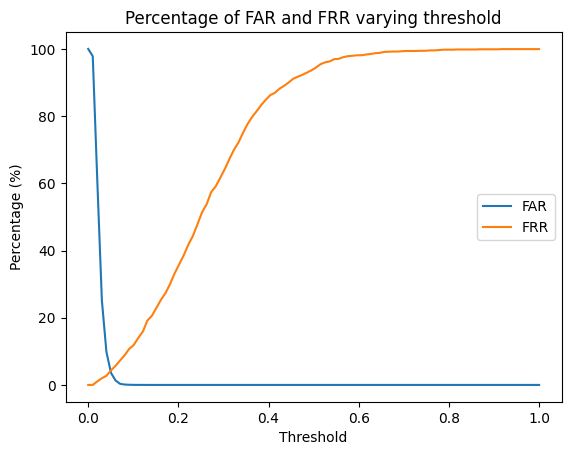

In [ ]:
#Plot FAR, FRR vs threshold

fig, ax = plt.subplots()
line = ax.plot(th, FAR, label='FAR')
line2 = ax.plot(th, FRR, label= 'FRR')
ax.set(xlabel='Threshold', ylabel='Percentage (%)',
       title='Percentage of FAR and FRR varying threshold')
ax.legend()
# ax.set_ylim([0,10]) #Uncomment this to zoom cross point
# ax.set_xlim([0,0.2])#Uncomment this to zoom cross point
plt.show()


As you can see, the FRR and FAR of the fingerprint recognition system change with the threshold varying.  In particular, we can notice that:

 - At the **Increasing** of the threshold:
1.   *increases* the FRR.
2.   *decreases* the FAR.
 - At the **Decreasing** of the threshold:
  1.   *decreases* the FRR.
  2.   *increases* the FAR.

If you have correctly completed the code above, you may have noticed that the two curves cross at one point.
Well, if we do not know what specific FRR and FAR would be considered the most suitable, we can choose to operate our system at the threshold at which the FRR and FAR are approximately equal.  This point is referred to as the **Equal Error Rate (EER)**.  The EER is often used to compare different fingerprint recognition systems (i.e., the lower the EER, the better the system) or databases (i.e., the lower the EER, the better quality or easier the database), since it serves as a good general compromise between the FRR and FAR.

The point at which the two curves **intersect** gives us an approximation for our EER.  

To do this, run the code below.

In [ ]:
# EER Estimation

index = np.where(abs(FAR-FRR) == np.amin(abs(FAR-FRR))) #searching for index that best approximates the cross point
EER=(FAR[index]+FRR[index])/2 #EER is a mean of the value corresponding to that index
print('The Equal Error Rate (EER) is', round(EER[0], 2), '%')

The Equal Error Rate (EER) is 3.97 %


### Step 5.2 Receiver Operating Characteristic (ROC) curve

Another common way of evaluating and comparing the recognition accuracy of different fingerprint recognition systems or databases is in terms of the **Receiver Operating Characteristic (ROC)** curve.  The ROC is a plot of the *Genuine Acceptance Rate*, which is 1 - FRR (or 100 - FRR in %), versus the *False Acceptance Rate*.

The closer an ROC curve is to the **top left corner** (i.e., the point at which FAR = 0 and 1 - FRR = 100), the better. This is because, at this point, the error rate is 0, i.e., all <font color =green>**genuine**</font> comparisons are considered a <font color =green>**Match**</font> and all <font color =red>**impostor**</font> comparisons are considered a <font color =red>**No Match**</font>.

The ROC curve gives us more information than the EER on its own, since it shows us the effects of the FAR and FRR on each other. The EER only tells us the error rate we can expect if we wish to minimise both the FAR and the FRR, while the ROC shows us how one error rate affects the other. For example, we can use the ROC to determine the expected FRR (inferred from 100 - FRR) at a specific FAR, and vice-versa. This could be useful if we wished to tune our fingerprint recognition system to operate at a point other than the EER.

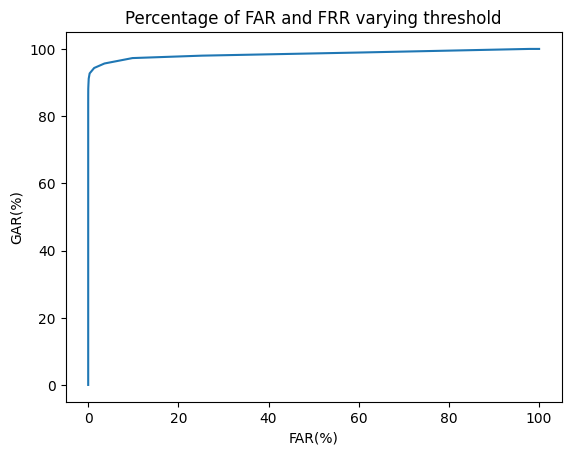

In [ ]:
#Plot FAR vs GAR aka ROC curve

fig, ax = plt.subplots()
ax.plot(FAR, 100-FRR)
ax.set(xlabel='FAR(%)', ylabel='GAR(%)',
       title='Percentage of FAR and FRR varying threshold')
plt.show()

## Now it's your turn!

Use this GDrive ID to download another little dataset to carry out the procedure that you have just learnt.

ID: **1bUlirdO-YBHFEBejJ90L2PrFguyCzBnL**

Compare the results in term of EER and ROC with the previous one.

You can start from the Feature Extraction part, adapting the code once you have understood the characteristics of the new dataset.

<center><font color=red size=4> !! Remember, pay attention not to overwrite variables' names!! </font>

In [3]:
#Download Dataset2 part
from IPython.display import clear_output

#lets import the dataset
!gdown --id "1bUlirdO-YBHFEBejJ90L2PrFguyCzBnL" -O Dataset2.zip
!unzip Dataset2.zip

#but also the needed functions from part 1
!gdown --id "1bOI_Wy77foeBPJVp_ITHpyhq_GwJtUpO" -O Tutorial2.zip
!unzip Tutorial2.zip
clear_output()

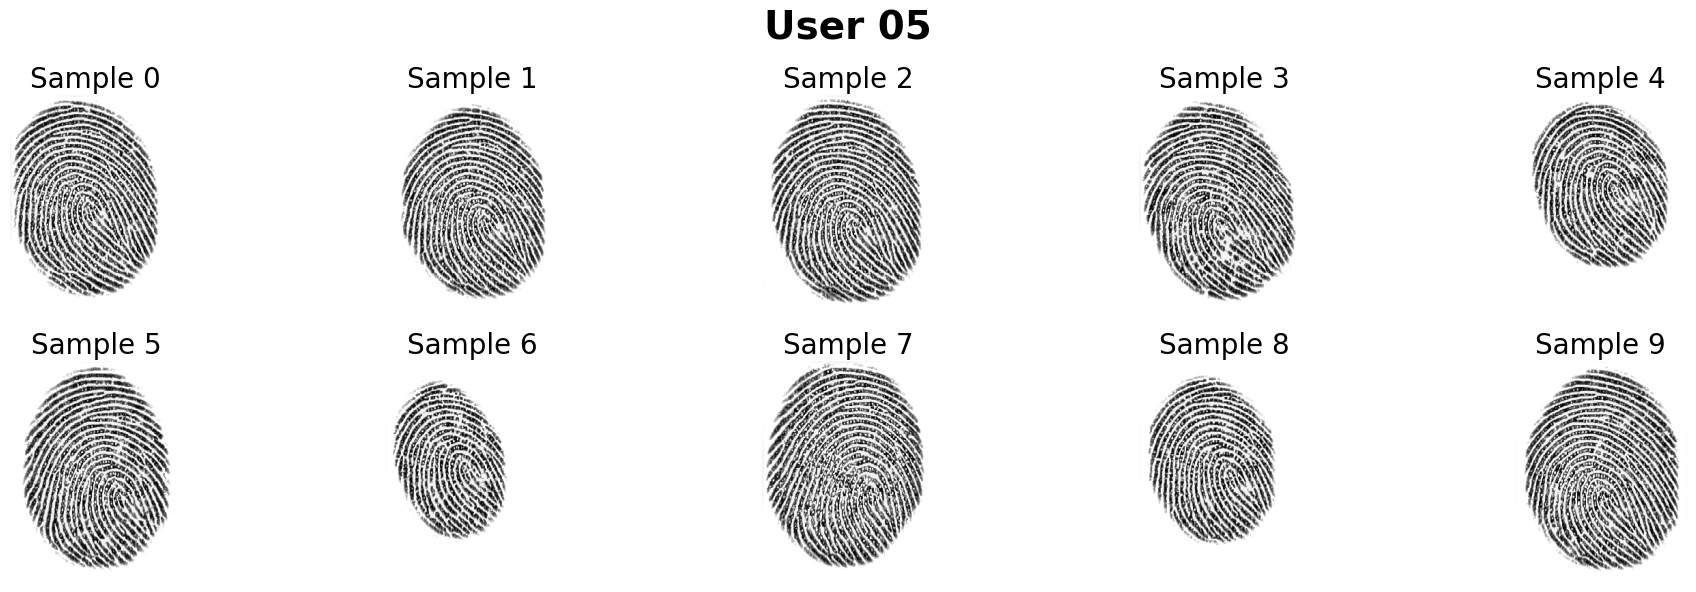

In [16]:
#Feature Extraction part


#firstly we create a function that shows us the dataset elements:

import math
import cv2
import numpy as np
from matplotlib import pyplot as plt


def shows(user, sample=None):
  user = user.zfill(2)

  if sample is None:
    fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(20, 6), sharex=True, sharey=True)
    for i in range(10):
      img = cv2.imread('dataset2/'+user+'_'+str(i)+'.jpeg')
      axes[int(math.floor(i/5)),int(i-5*(math.floor(i/5)))].set_title('Sample '+str(i), fontsize=20)
      axes[int(math.floor(i/5)),int(i-5*(math.floor(i/5)))].axis('off')
      axes[int(math.floor(i/5)),int(i-5*(math.floor(i/5)))].imshow(img, cmap=plt.cm.gray)

  if sample is not None:
    fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 6))
    img = cv2.imread('dataset2/'+user+'_'+sample+'.jpeg')
    ax.set_title('Sample '+sample, fontsize=20)
    ax.axis('off')
    ax.imshow(img, cmap=plt.cm.gray)

  plt.suptitle('User '+ user, fontsize=28, fontweight="bold")
  fig.tight_layout()
  plt.show()

user = "05"
shows(user)

In [6]:
# Now we can perform feature extraction
import os
import subprocess
import numpy as np

# code for progress bar

from IPython.display import HTML, display
import time

def progress(value, max=100):
    return HTML("""
        <progress
            value='{value}'
            max='{max}',
            style='width: 100%'
        >
            {value}
        </progress>
    """.format(value=value, max=max))

# now the proper feature extraction

samples = os.listdir('/content/dataset2') #path of the dataset
!chmod 755 mindtct #allows to read and execute the file
print('Current Progress...')
out = display(progress(0, len(samples)-1), display_id=True)

for idx,fp in enumerate(samples):
  #Check slide 14 of this Tutorial and understand the command expressed by the string below
  os.system('/content/mindtct -m1 -b /content/dataset2/'+ fp + ' /content/dataset2/' + fp[0:4])
  out.update(progress(idx, len(samples)-1))

Current Progress...


/tmp/ipython-input-1045354220.py:62: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  plt.imshow(qm_expanded, cmap = plt.cm.get_cmap('prism', 5), alpha = 0.3)


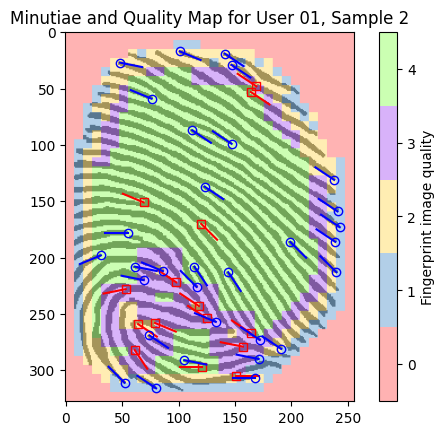

In [31]:
#score and legend computing part


def read_minutiae(filename):
    # Extract minutiae attributes
    with open(filename) as f:
        minutiae_temp = [line.strip().split(':') for line in f][4:]
    coords = np.array([ln[1].split(',') for ln in minutiae_temp], dtype=int)
    xs = coords[:, 0]
    ys = coords[:, 1]
    angles = np.array([ln[2] for ln in minutiae_temp], dtype=int)
    types = np.array([ln[4].strip() for ln in minutiae_temp]) # strip() removes the space after the minutia type
    # Calculate start and end coordinates of vectors representing minutiae coordinates and angles
    num_minutiae = len(xs)
    line_len = 20
    start_xs = np.array(xs)
    start_ys = np.array(ys)
    angles_rad = angles * 11.25 / 180.0 * math.pi # Convert angles to radians
    end_xs = np.array([start_xs[ind] + line_len * math.sin(angles_rad[ind]) for ind in range(0, num_minutiae)])
    end_ys = np.array([start_ys[ind] - line_len * math.cos(angles_rad[ind]) for ind in range(0, num_minutiae)])

    return start_xs, end_xs, start_ys, end_ys, types

# Function to display the minutiae on the binarised image, on top of the Quality Map
def display_fp(user,sample,display_quality,display_minutiae):

    #its important to firstly get the image shape. Assuming that all dataset image have the same dimensions:
    filename = 'dataset2/'+user+'_'+sample
    img = cv2.imread(filename+".jpeg")
    dim = (img.shape[0],img.shape[1])

    if(display_minutiae):
      # Read minutiae attributes, and calculate start and end coordinates of vectors representing minutiae coordinates and angles
      [start_xs, end_xs, start_ys, end_ys, types] = read_minutiae(filename + '.min')
      # Plot bifurcation (BIF) minutiae coordinates and angles
      bif_mask = types == 'BIF'
      plt.plot(start_xs[bif_mask], start_ys[bif_mask], 's', markeredgecolor = 'red', markerfacecolor = 'None')
      plt.plot([start_xs[bif_mask], end_xs[bif_mask]], [start_ys[bif_mask], end_ys[bif_mask]], color = 'red')
      # Plot termination/ridge ending (RIG) minutiae coordinates and angles
      rig_mask = types == 'RIG'
      plt.plot(start_xs[rig_mask], start_ys[rig_mask], 'o', markeredgecolor = 'blue', markerfacecolor = 'None')
      plt.plot(np.array([start_xs[rig_mask], end_xs[rig_mask]]), np.array([start_ys[rig_mask], end_ys[rig_mask]]), color = 'blue')

      bin_img = bytearray(open(filename + '.brw', 'rb').read()) # load binarised
      bin_img = np.reshape(bin_img,dim)
      plt.imshow(bin_img, alpha=0.5,cmap='gray') #change alpha to change opaqueness
      tit = f"Minutiae Minutiae and Quality Map for User {user}, Sample {sample}"
    else:

      bin_img = bytearray(open(filename + '.brw', 'rb').read()) # load binarised
      bin_img = np.reshape(bin_img,dim)
      plt.imshow(bin_img, alpha=1,cmap='gray') #change alpha to change opaqueness
      tit = f"Binarized image Minutiae and Quality Map for User {user}, Sample {sample}"

    if(display_quality):
      with open(filename + '.qm') as f: #load quality map
              qm_temp = [list(filter(None, ln[0].split(' '))) for ln in [line.strip().split(',') for line in f]]
      qm = np.array(qm_temp, dtype=float)
      qm_expanded = np.repeat(qm, 8, axis = 0)
      qm_expanded = np.repeat(qm_expanded, 8, axis = 1)
      # Plot Quality Map
      plt.imshow(qm_expanded, cmap = plt.cm.get_cmap('prism', 5), alpha = 0.3)
      plt.colorbar(ticks = range(5), label = 'Fingerprint image quality')
      plt.clim(-0.5, 4.5)
      tit = f"Minutiae and Quality Map for User {user}, Sample {sample}"


    # Display the minutiae and Quality Map on the binarised fingerprint image
    plt.title(tit)
    plt.show()


user = '01'
sample = '2'
display_minutiae = True
display_quality = True


display_fp(user,sample,display_quality,display_minutiae)

In [132]:
#Comparison part


# comparison between the same fingerprint, score should be very high since the extracted features are the same
# this event should never appen in practice
probe_fingerprint = '/content/dataset2/07_0.xyt'
gallery_fingerprint = '/content/dataset2/07_0.xyt'
!chmod 755 bozorth3
cmd = '/content/bozorth3 -m1 '+ probe_fingerprint + ' ' + gallery_fingerprint
print("- Same fingertip sample comparison score = "+ subprocess.check_output(cmd, shell=True).decode("utf-8"))

# comparison of two different sample of the same fingerprint
# (this scenario is closer to reality since fingerprint samples are never perfectly identical)

probe_fingerprint = '/content/dataset2/07_0.xyt'
gallery_fingerprint = '/content/dataset2/07_5.xyt'
cmd = '/content/bozorth3 -m1 '+ probe_fingerprint + ' ' + gallery_fingerprint
print("- Different fingertip samples of the same fingertip score = "+ subprocess.check_output(cmd, shell=True).decode("utf-8"))


# comparison of two different fingertips, also called impostor comparison
# it should return a very low score

probe_fingerprint = '/content/dataset2/07_0.xyt'
gallery_fingerprint = '/content/dataset2/08_5.xyt'
cmd = '/content/bozorth3 -m1 '+ probe_fingerprint + ' ' + gallery_fingerprint
print("- Impostor comparison = "+ subprocess.check_output(cmd, shell=True).decode("utf-8"))

#Now lets check create an algorithm that returns the most probable person to which the chosen fingertip belongs to

user = "02"
sample = "3"
data = {}

probe_fingerprint = f"/content/dataset2/{user}_{sample}.xyt"

for element in os.listdir('/content/dataset2'):

    if not element.endswith(".xyt"):
        continue

    cmd = f'/content/bozorth3 -m1 "{probe_fingerprint}" "/content/dataset2/{element}"'
    output = subprocess.check_output(cmd, shell=True).decode("utf-8").strip()
    user2 = element[:2]
    if user2 in data:
        data[user2] += int(output)
    else:
        data[user2] = int(output)


print(f"comparison between User {user} and dataset....")
best_user = max(data, key=data.get)
print(f"\nthe given fingerprint ( User = {user} Sample = {sample})"
f"\ncorresponds to the one of user = {best_user} Score = {data[best_user]/10}")


print(f"\n----other scores:----\n")
for user, score in sorted(data.items()):
    print(f"User = {user} Score = {score/10}")


- Same fingertip sample comparison score = 489

- Different fingertip samples of the same fingertip score = 74

- Impostor comparison = 23

comparison between User 02 and dataset....

the given fingerprint ( User = 02 Sample = 3)
corresponds to the one of user = 02 Score = 69.8

----other scores:----

User = 01 Score = 8.0
User = 02 Score = 69.8
User = 03 Score = 8.8
User = 04 Score = 6.0
User = 05 Score = 11.8
User = 06 Score = 6.4
User = 07 Score = 13.7
User = 08 Score = 8.4
User = 09 Score = 4.3
User = 10 Score = 7.1
User = 11 Score = 5.3
User = 12 Score = 8.0
User = 13 Score = 7.4
User = 14 Score = 4.7
User = 15 Score = 6.3
User = 16 Score = 2.6
User = 17 Score = 7.7
User = 18 Score = 7.4
User = 19 Score = 3.8
User = 20 Score = 8.5
User = 21 Score = 6.2
User = 22 Score = 9.6
User = 23 Score = 6.4
User = 24 Score = 4.7
User = 25 Score = 6.5
User = 26 Score = 5.5
User = 27 Score = 8.8
User = 28 Score = 8.7
User = 29 Score = 7.2
User = 30 Score = 6.5
User = 31 Score = 4.3
User = 32 Sc

Performing matching...it will take about 5 minutes...perfect time for a break ☕


Time elapsed: 323.23 s


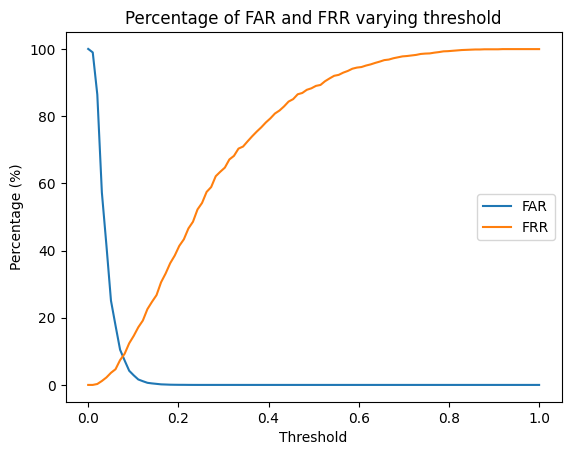

The Equal Error Rate (EER) is 8.28 %


In [38]:
#FAR, FRR and EER part

# Error computation

import time,glob

gallery=sorted(glob.glob('/content/dataset2/*.xyt')) #path of the dataset. *.xyt allows to take only files that ends with .xyt

#~~~~~~~~~create a support vector to compute legend matrix~~~~~~~~~~~~~~~~~~~~~

idV = np.zeros((1,len(gallery)),dtype=int) #
for i,el in enumerate(gallery):
  idV[0,i]=int(el[-8:-6])

#~~~~~~~~~~~~~~~~~~~Generate .lis file~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

listname='gallery.lis' #save in this file all fingerprint paths.
fileID = open(listname,'w');
for el in gallery:
    fileID.write(el+'\n')
fileID.close()

#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

t = time.time()
#~~~~~~~~~~~~~~~~~~~~~~~~initialize matrices~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

scores=np.zeros((len(gallery),len(gallery)),dtype=int)
legend=np.ones((len(gallery),len(gallery)),dtype=int)*(-1) # 1 = genuine; 0 = imposter; -1 = not valid

#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
!chmod 755 bozorth3 #it allows to execute bozorth3

print('Performing matching...it will take about 5 minutes...perfect time for a break ☕')
out = display(progress(0, len(gallery)-2), display_id=True) #optional: initialize the progress bar

for ii in range(len(gallery)-1):
  probe=gallery[ii]
  cID = int(probe[-8:-6]) #current ID taken from probe path

  #Check slide 21 of this Tutorial to understand the command expressed by the string below
  cmd = '/content/bozorth3 -m1 -A glines='+str(ii+2)+'-400 -p '+ probe +' -G /content/gallery.lis'
  output = subprocess.check_output(cmd, shell=True).decode("utf-8")

  #store command results
  scores[ii,ii+1:] = np.array(output.splitlines(), dtype=int)
  legend[ii,ii+1:] = (idV[0,ii+1:] == cID)*1  # *1 to force True --> 1

  out.update(progress(ii, len(gallery)-2)) #optional: update the progress bar

elapsed = 'Time elapsed: %.2f s' %(time.time() - t)
print(elapsed)



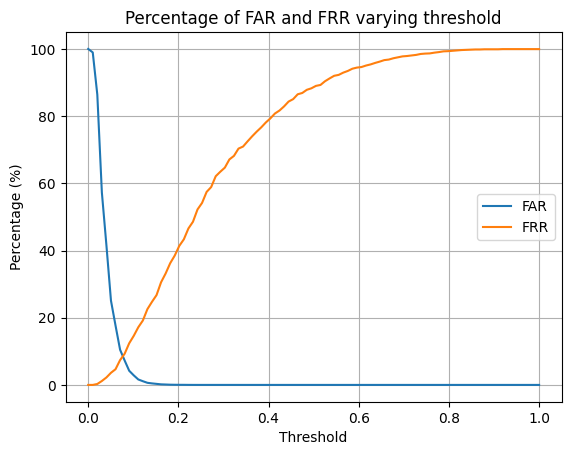

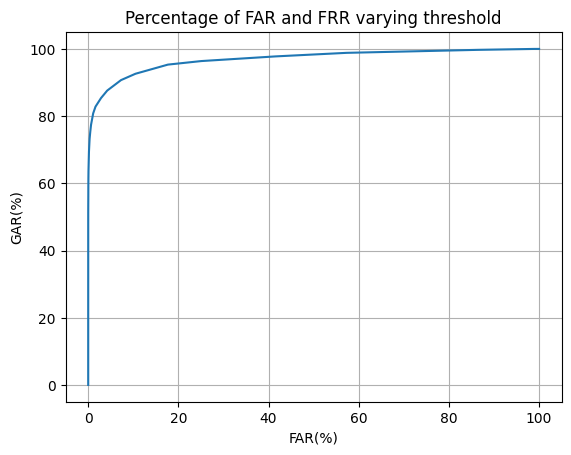

The Equal Error Rate (EER) is 8.28 %


In [40]:

# ------------- NOW THE SCORES ARE COPUTED, LETS ANALYZE THE ERRORS -------------

#Separate scores of genuines and impostors

genuines = scores[legend==1]
impostors = scores[legend==0]

#scores normalization in range [0,1]

mx = max(np.concatenate((genuines,impostors),axis=0))
mn = min(np.concatenate((genuines,impostors),axis=0))

genuines = (genuines - mn)/(mx-mn)
impostors = (impostors - mn)/(mx-mn)

#Inizialize arrays for FRR and FAR storage
FRR=np.zeros((100,1))
FAR=np.zeros((100,1))

#We set a 100 points threshold, from 0 (all users accepted) to 1 (nobody refused).
#P.S. We can do this because now the match scores are normalized.
th=np.linspace(0,1,100);


for i,t in enumerate(th):

  # "t" is the threshold value for each iteration

  count=len(np.argwhere(impostors>=t))   #change ___ with the right comparison for FAR
  FAR[i,0]= 100*count/len(impostors)     #complete the formula (remember that FAR is a % value)

  count=len(np.argwhere(genuines<t))  #change ___ with the right comparison for FRR
  FRR[i,0]=100*count/len(genuines)    #complete the formula (remember that FRR is a % value)


#Plot FAR, FRR vs threshold

fig, ax = plt.subplots()
line = ax.plot(th, FAR, label='FAR')
line2 = ax.plot(th, FRR, label= 'FRR')
ax.set(xlabel='Threshold', ylabel='Percentage (%)',
       title='Percentage of FAR and FRR varying threshold')
ax.legend()
ax.grid(True)
# ax.set_ylim([0,10]) #Uncomment this to zoom cross point
# ax.set_xlim([0,0.2])#Uncomment this to zoom cross point
plt.show()


#Plot FAR vs GAR aka ROC curve

fig, ax = plt.subplots()
ax.plot(FAR, 100-FRR)
ax.set(xlabel='FAR(%)', ylabel='GAR(%)',
       title='Percentage of FAR and FRR varying threshold')
ax.grid(True)
plt.show()


# EER Estimation

index = np.where(abs(FAR-FRR) == np.amin(abs(FAR-FRR))) #searching for index that best approximates the cross point
EER=(FAR[index]+FRR[index])/2 #EER is a mean of the value corresponding to that index
print('The Equal Error Rate (EER) is', round(EER[0], 2), '%')


## Conclusions

Summing up the tutorial of today, designing this simple fingerprint matcher, we:

 - Looked at and understood the output of mindtct feature extractor (quality maps, binarised fingerprints, minutiae).
 - Compared fingerprints in both a verification and an identification scenario.
 - Considered the effect of the match threshold on the decision of a fingerprint recognition system.
 - Gained insight into how the match threshold affects the False Rejection Rate (FRR) and False Acceptance Rate (FAR).
 - Learnt how to calculate the Equal Error Rate (EER), and understood the significance of the EER in comparing different fingerprint datasets.
 - Compared the Receiver Operating Characteristic (ROC) curves across our two fingerprint datasets, and considered the advantages of the ROC over the EER in making this comparison.

In [66]:
import zipfile
import os

# Define the path to the original zip file
zip_file_path = 'Tutorial2.zip'

# Define the directory to extract to (usually the current directory in Colab)
extract_path = '.'

# Check if the zip file exists before attempting to extract
if os.path.exists(zip_file_path):
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print(f"Contents of {zip_file_path} extracted to {extract_path}")
else:
    print(f"Error: {zip_file_path} not found. Please ensure the original zip file is in the correct location.")

Error: Tutorial2.zip not found. Please ensure the original zip file is in the correct location.


In [68]:
import os
import shutil

folder_path = '/content'
for item in os.listdir(folder_path):
    item_path = os.path.join(folder_path, item)
    if os.path.isfile(item_path):
        os.remove(item_path)
    elif os.path.isdir(item_path):
        shutil.rmtree(item_path)
print(f"Contents of {folder_path} cleared.")

Contents of /content cleared.
